# Histogram task tied exp

In [24]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

# run_id = "20251117_0801"  # rho = 2, d = 100, seq_len = 30
# run_id = "20251117_0814" # rho = 1, d = 100, seq_len = 30
# run_id = "20251117_0845" # rho = 1, d = 100, seq_len = 15
# run_id = "20251117_0906" # rho = 0.75, d = 100, seq_len = 30
run_id = "20251117_0942" # rho = 0.75, d = 100, seq_len = 30

## 1. experiment config

In [25]:
# --- Path to your local folder ---
config_path = f"../results/run_{run_id}/config.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (20 rows) from ../results/run_20251117_0942/config.csv


,D,L,alpha,rho,beta,lam_list,Delta_list,Delta_in,samples,T,...,N_test,seq_len,device,logger,run_dir,run_index,seed,R,N_train,N_total
0,100,15,0.078947,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_1_2725505 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,75,789,2789
1,100,15,0.107895,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_2_2725506 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,75,1078,3078
2,100,15,0.136842,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_3_2725507 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,75,1368,3368
3,100,15,0.194737,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_5_2725509 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,75,1947,3947
4,100,15,0.223684,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_6_2725510 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,75,2236,4236
5,100,15,0.165789,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_4_2725508 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,75,1657,3657
6,100,15,0.252632,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_7_2725511 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,75,2526,4526
7,100,15,0.310526,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_9_2725513 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,9,42,75,3105,5105
8,100,15,0.281579,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_8_2725512 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,75,2815,4815
9,100,15,0.339474,0.75,1.0,[0.01],[0.0],0.5,12,10000,...,2000,30,cuda,<Logger logger_10_2725514 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,10,42,75,3394,5394


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (20 rows) from ../results/run_20251117_0942/summary.csv


,alpha,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean
0,0.078947,0.01,0.75,NaN,0.0,0.000547,6.928970e-13,2.212311,7.827302e-10,2.212311
1,0.107895,0.01,0.75,NaN,0.0,0.000545,6.254016e-13,3.022646,7.732875e-10,3.022646
2,0.136842,0.01,0.75,NaN,0.0,0.000547,7.773827e-13,3.835787,7.808040e-10,3.835788
3,0.194737,0.01,0.75,NaN,0.0,0.000549,5.267792e-13,5.459272,7.732875e-10,5.459272
4,0.223684,0.01,0.75,NaN,0.0,0.000552,5.696701e-13,6.269600,7.732875e-10,6.269600


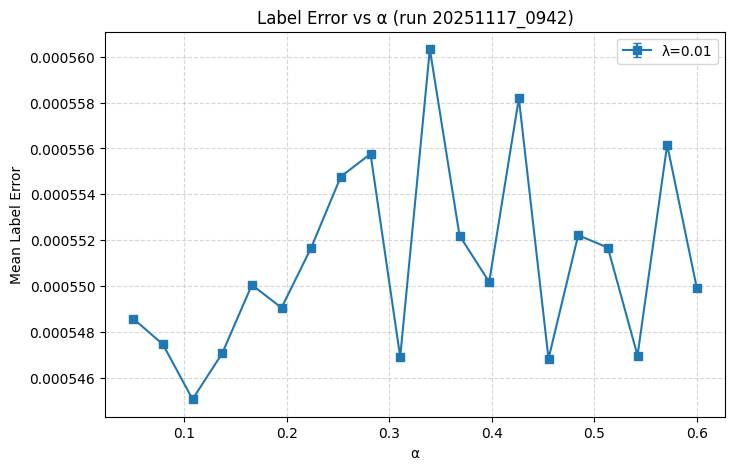

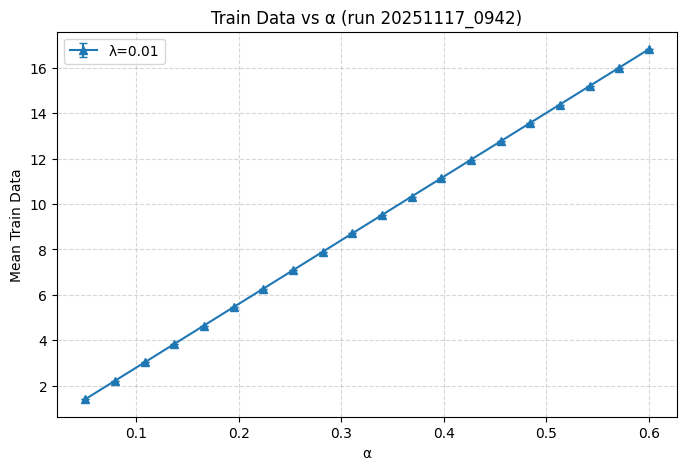

In [26]:
# --- Path to your local folder ---
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean"], yerr=subset.get("label_err_std", 0),
                 marker='s', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Label Error")
plt.title(f"Label Error vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Train Data")
plt.title(f"Train Data vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Results visualisation

Found 20 W_runs files.
Found 20 attn_run files.

[RUN] Processing ../results/run_20251117_0942/W_runs_0.pkl & ../results/run_20251117_0942/attn_run0.pkl (1 λ indices)


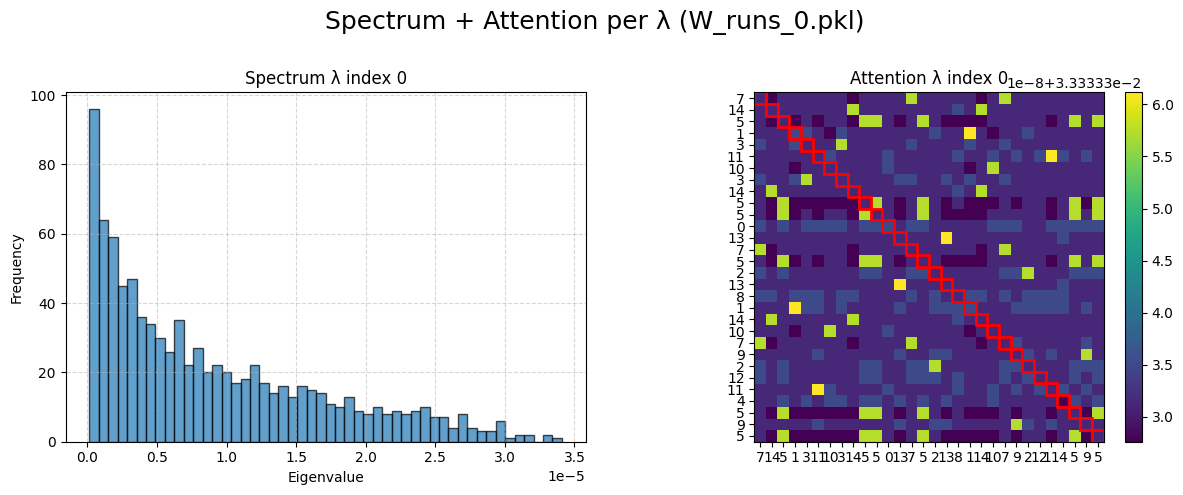


[RUN] Processing ../results/run_20251117_0942/W_runs_1.pkl & ../results/run_20251117_0942/attn_run1.pkl (1 λ indices)


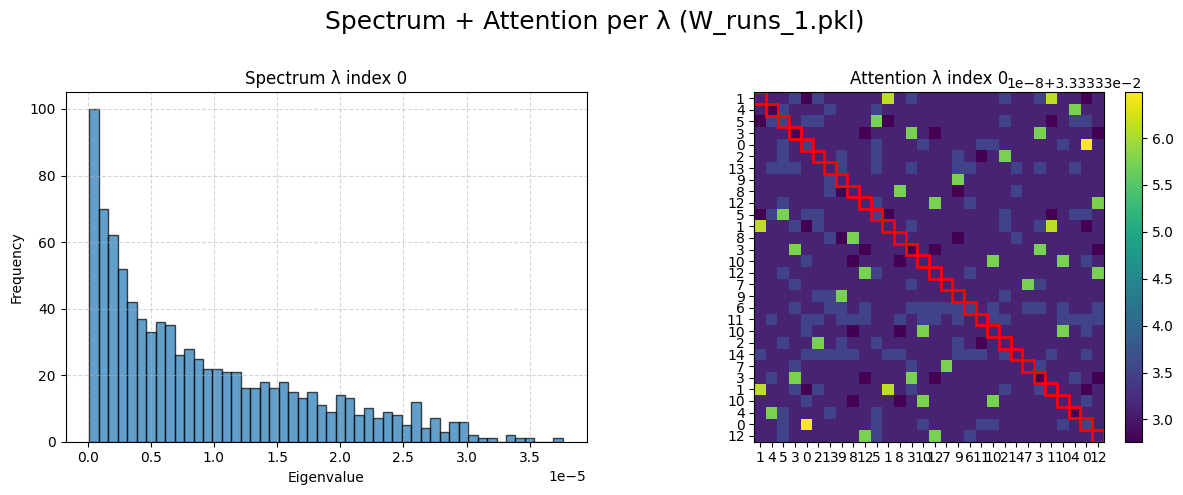


[RUN] Processing ../results/run_20251117_0942/W_runs_10.pkl & ../results/run_20251117_0942/attn_run10.pkl (1 λ indices)


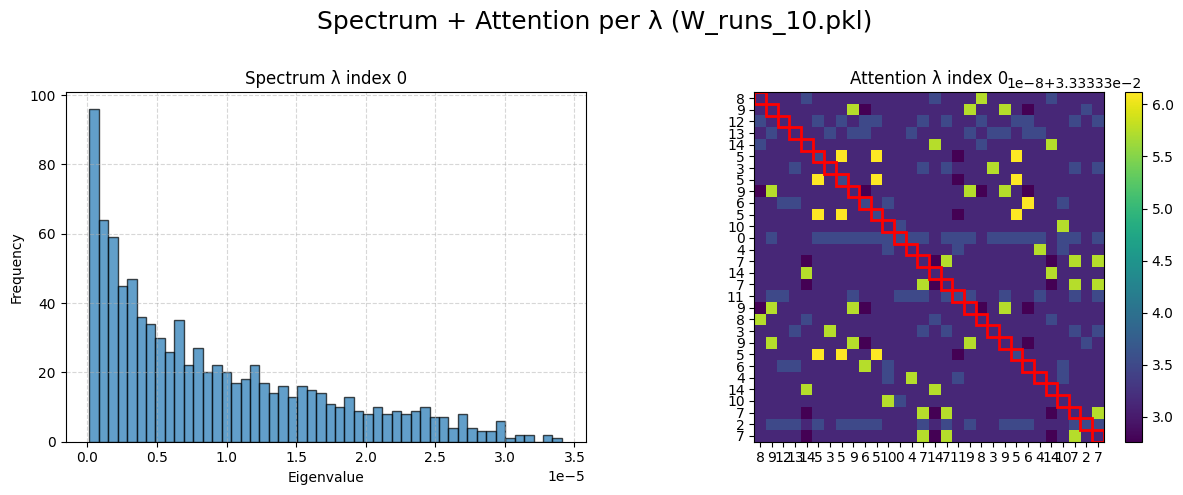


[RUN] Processing ../results/run_20251117_0942/W_runs_11.pkl & ../results/run_20251117_0942/attn_run11.pkl (1 λ indices)


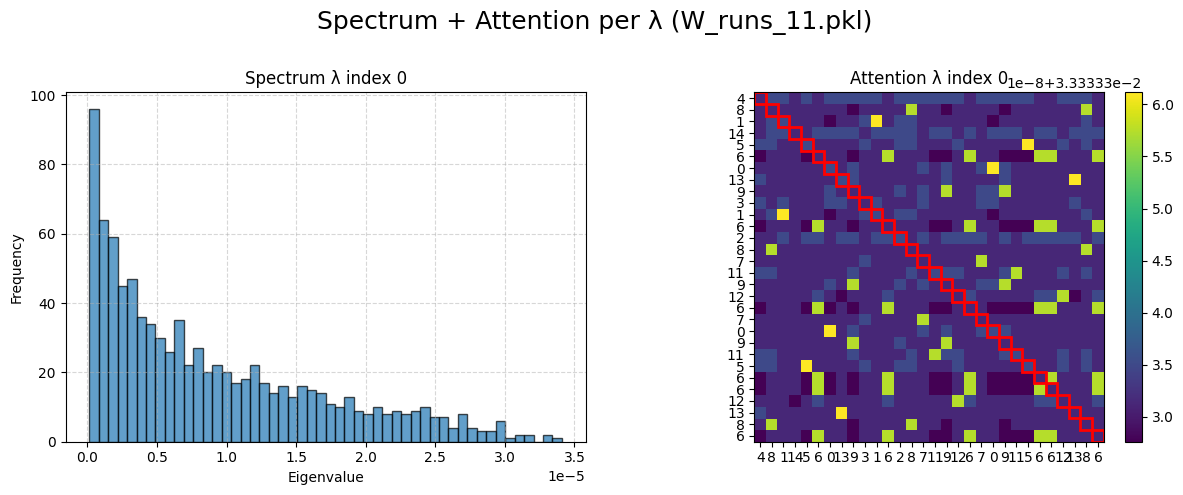


[RUN] Processing ../results/run_20251117_0942/W_runs_12.pkl & ../results/run_20251117_0942/attn_run12.pkl (1 λ indices)


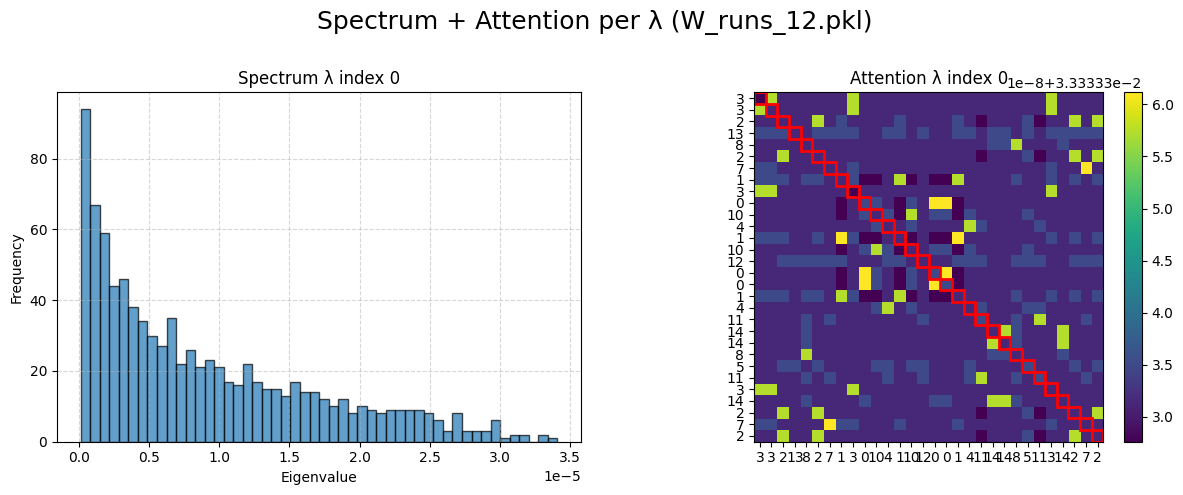


[RUN] Processing ../results/run_20251117_0942/W_runs_13.pkl & ../results/run_20251117_0942/attn_run13.pkl (1 λ indices)


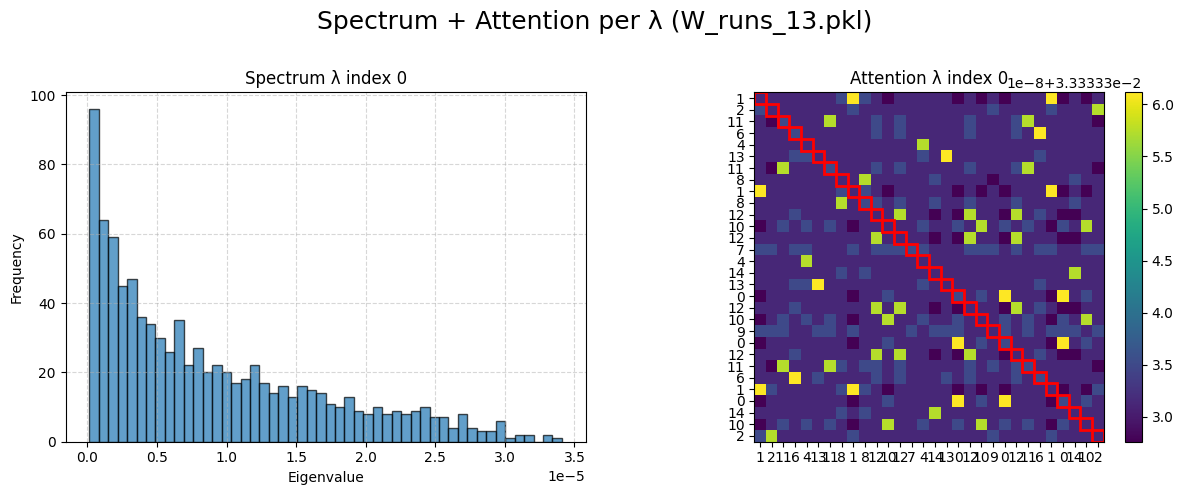


[RUN] Processing ../results/run_20251117_0942/W_runs_14.pkl & ../results/run_20251117_0942/attn_run14.pkl (1 λ indices)


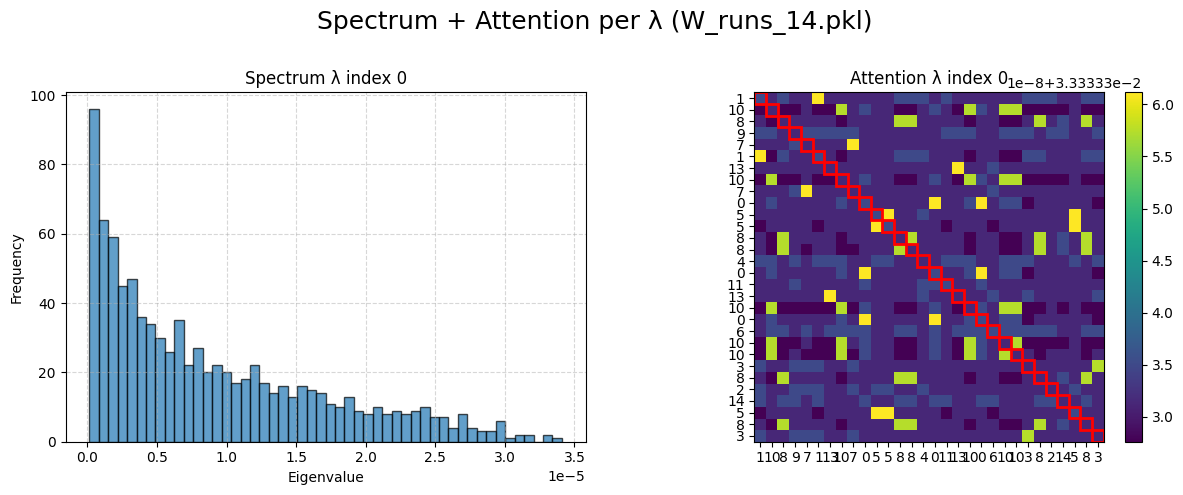


[RUN] Processing ../results/run_20251117_0942/W_runs_15.pkl & ../results/run_20251117_0942/attn_run15.pkl (1 λ indices)


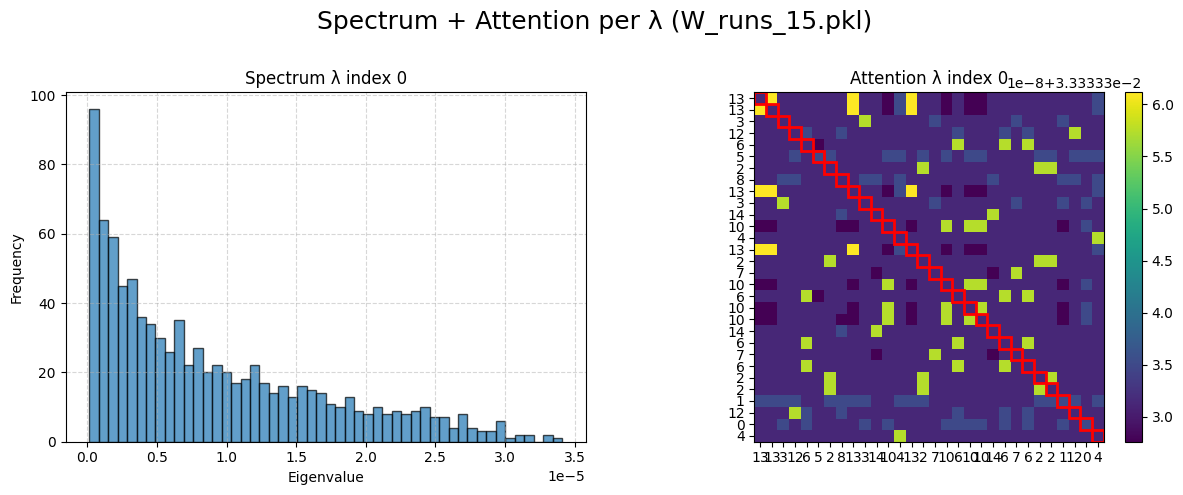


[RUN] Processing ../results/run_20251117_0942/W_runs_16.pkl & ../results/run_20251117_0942/attn_run16.pkl (1 λ indices)


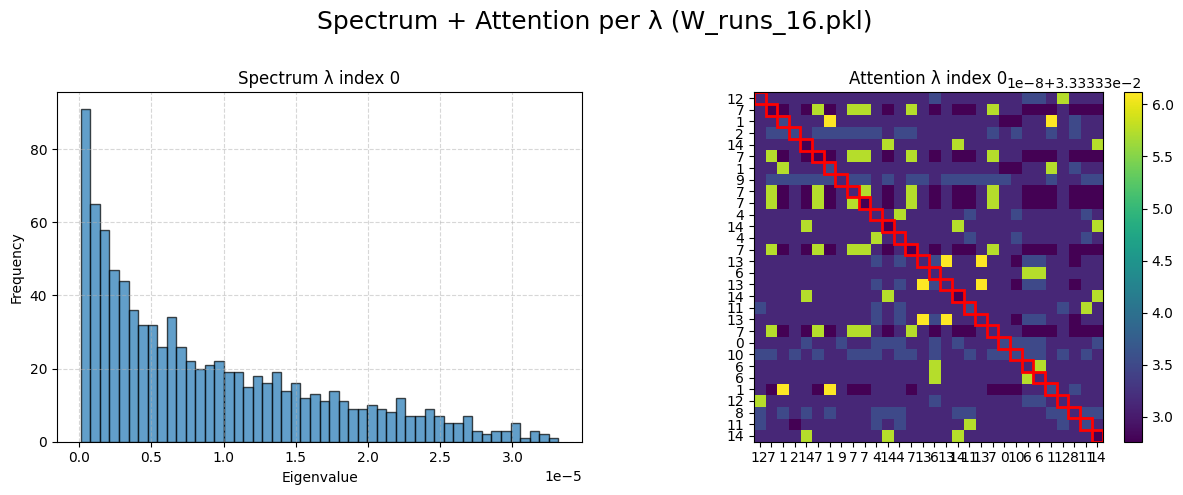


[RUN] Processing ../results/run_20251117_0942/W_runs_17.pkl & ../results/run_20251117_0942/attn_run17.pkl (1 λ indices)


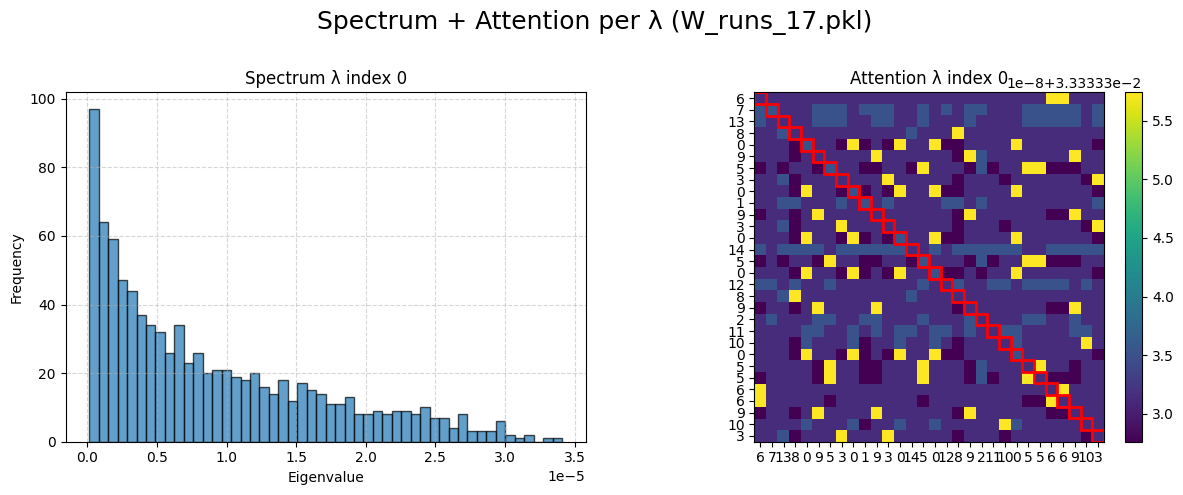


[RUN] Processing ../results/run_20251117_0942/W_runs_18.pkl & ../results/run_20251117_0942/attn_run18.pkl (1 λ indices)


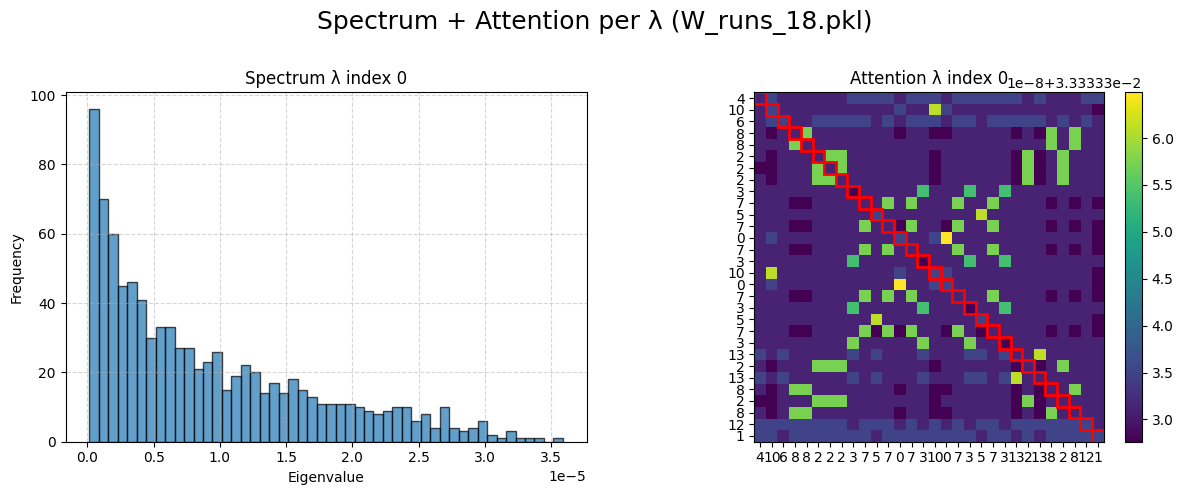


[RUN] Processing ../results/run_20251117_0942/W_runs_19.pkl & ../results/run_20251117_0942/attn_run19.pkl (1 λ indices)


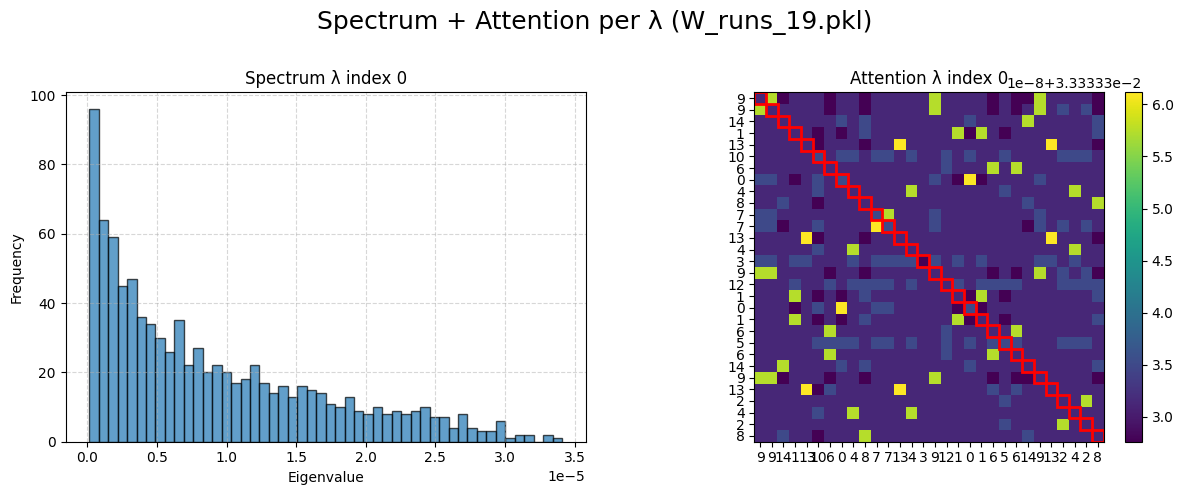


[RUN] Processing ../results/run_20251117_0942/W_runs_2.pkl & ../results/run_20251117_0942/attn_run2.pkl (1 λ indices)


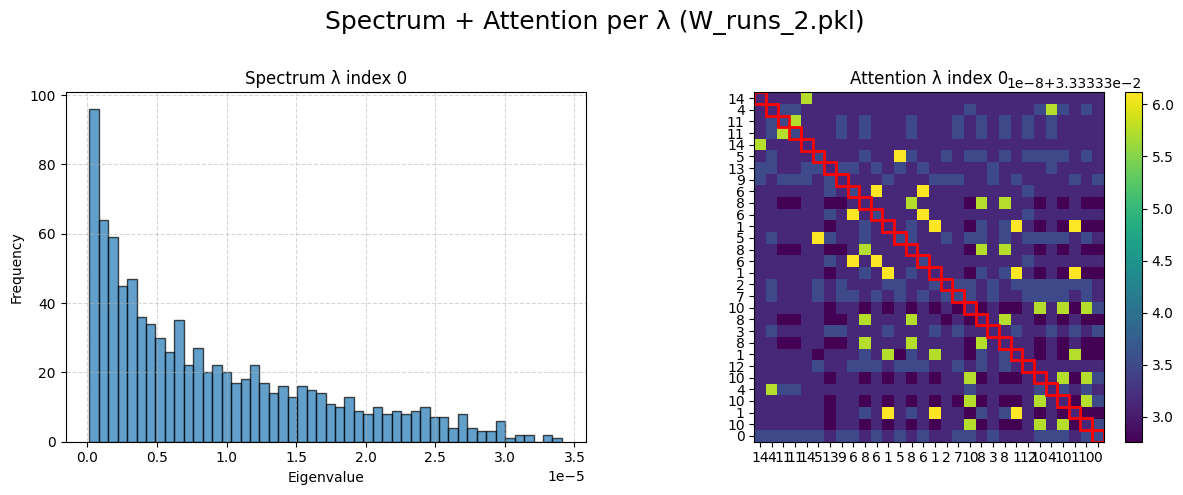


[RUN] Processing ../results/run_20251117_0942/W_runs_3.pkl & ../results/run_20251117_0942/attn_run3.pkl (1 λ indices)


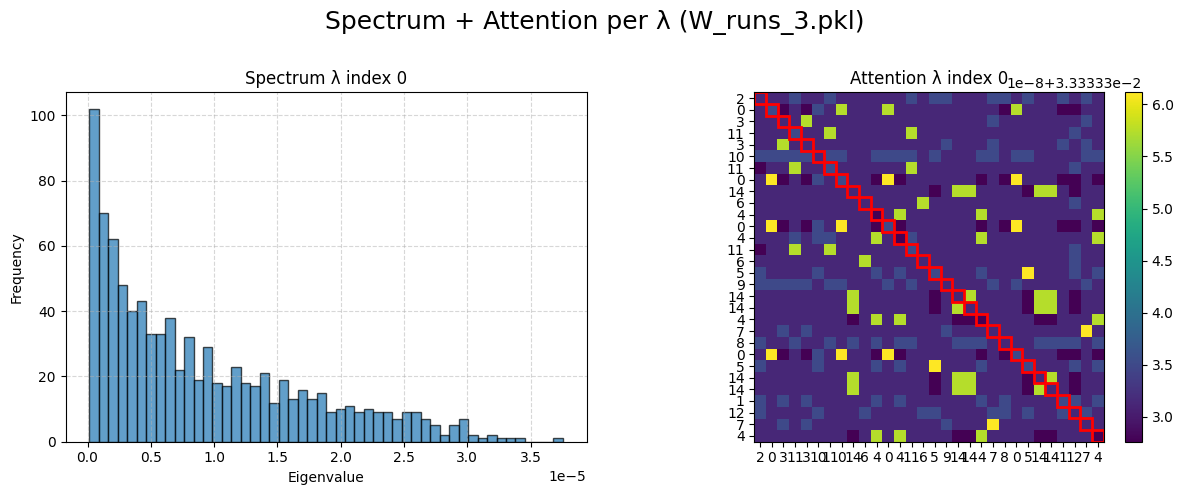


[RUN] Processing ../results/run_20251117_0942/W_runs_4.pkl & ../results/run_20251117_0942/attn_run4.pkl (1 λ indices)


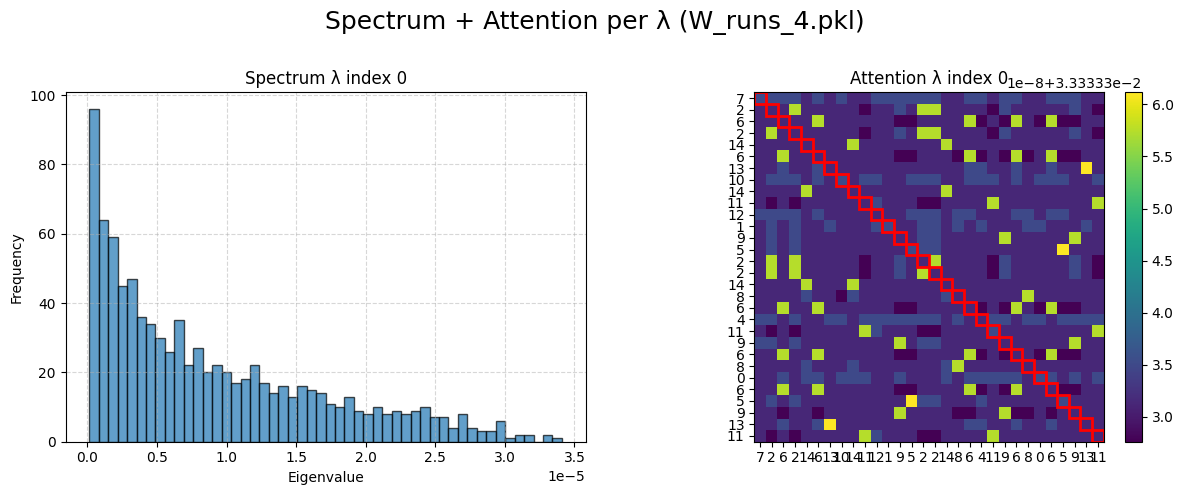


[RUN] Processing ../results/run_20251117_0942/W_runs_5.pkl & ../results/run_20251117_0942/attn_run5.pkl (1 λ indices)


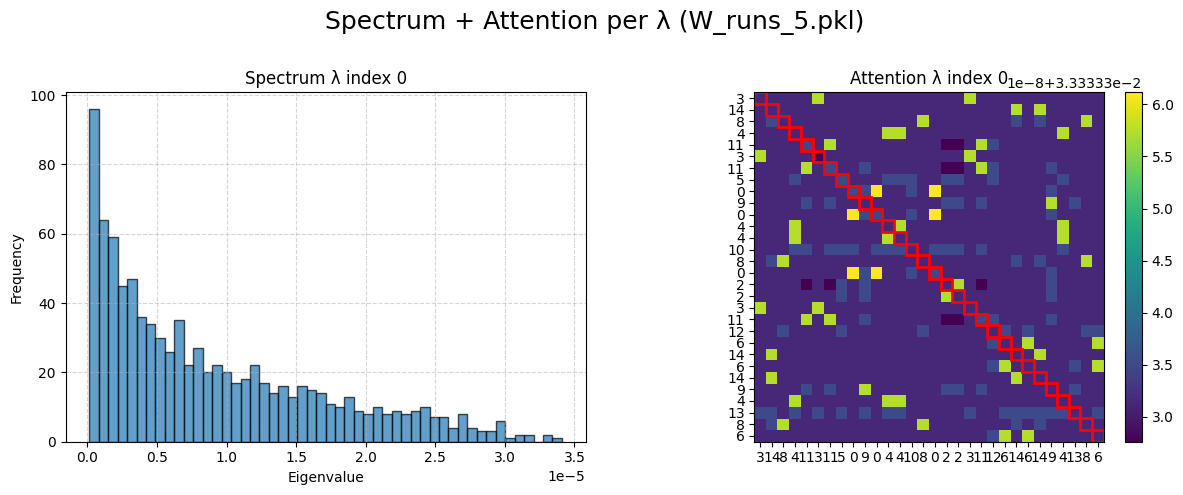


[RUN] Processing ../results/run_20251117_0942/W_runs_6.pkl & ../results/run_20251117_0942/attn_run6.pkl (1 λ indices)


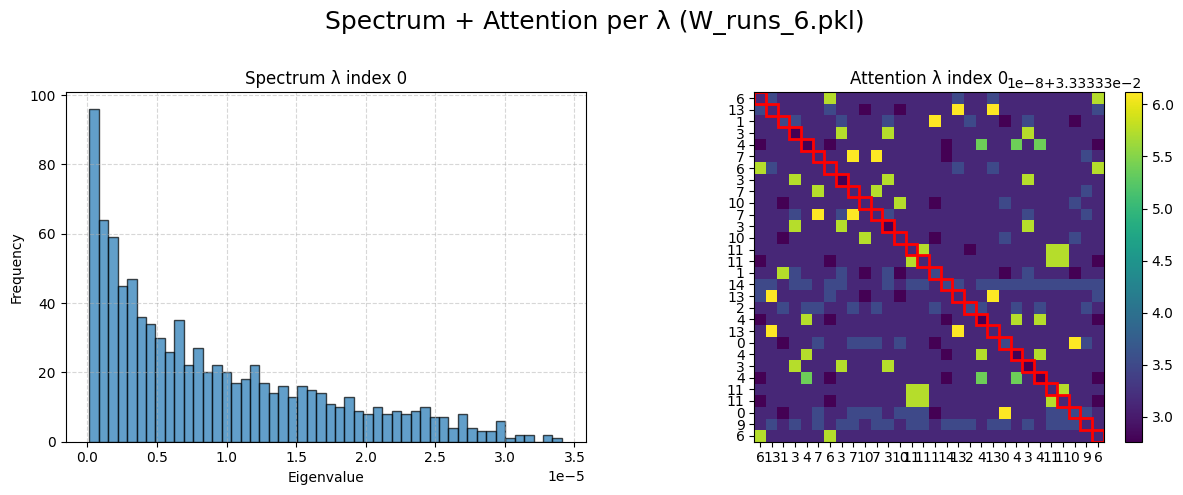


[RUN] Processing ../results/run_20251117_0942/W_runs_7.pkl & ../results/run_20251117_0942/attn_run7.pkl (1 λ indices)


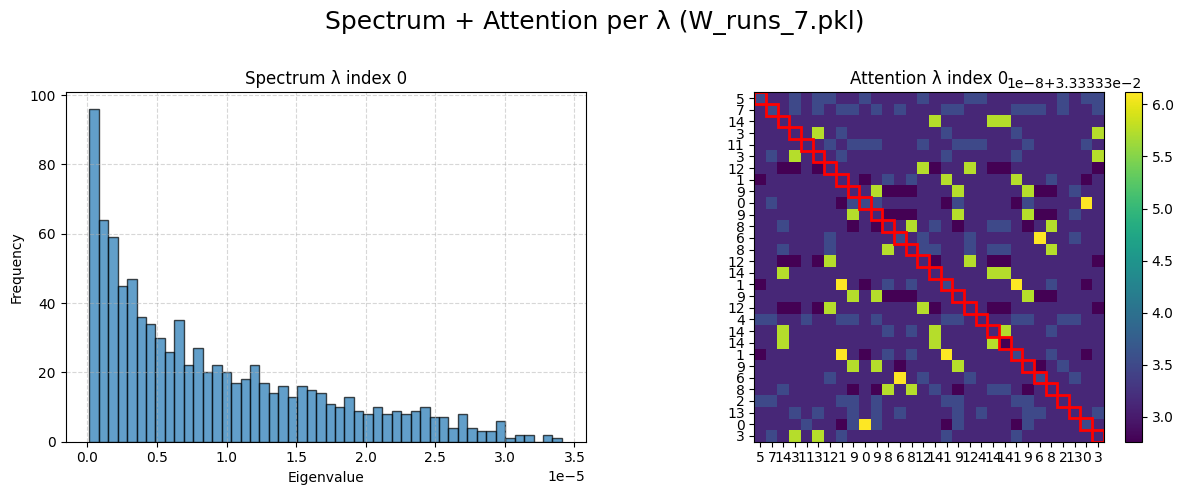


[RUN] Processing ../results/run_20251117_0942/W_runs_8.pkl & ../results/run_20251117_0942/attn_run8.pkl (1 λ indices)


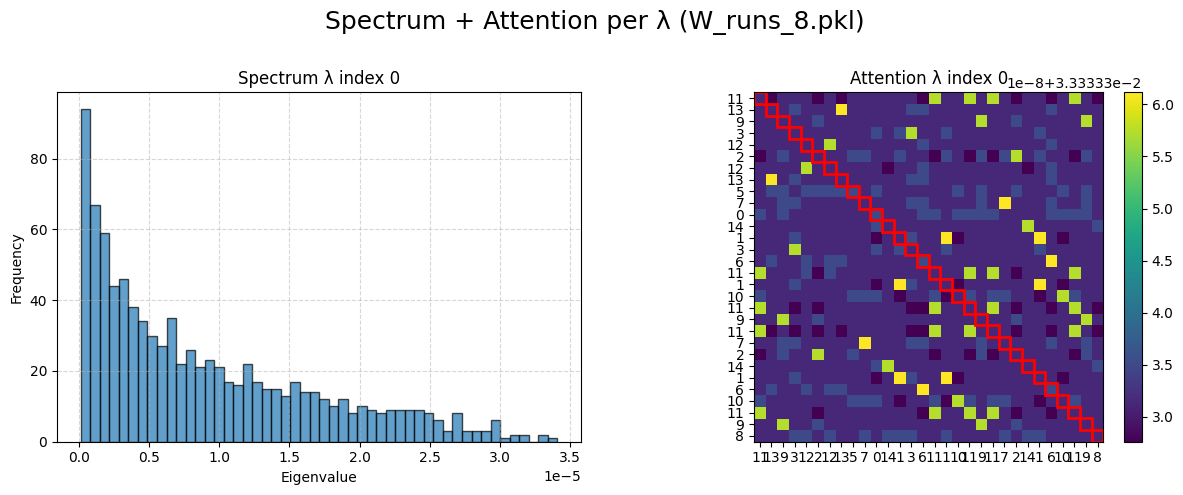


[RUN] Processing ../results/run_20251117_0942/W_runs_9.pkl & ../results/run_20251117_0942/attn_run9.pkl (1 λ indices)


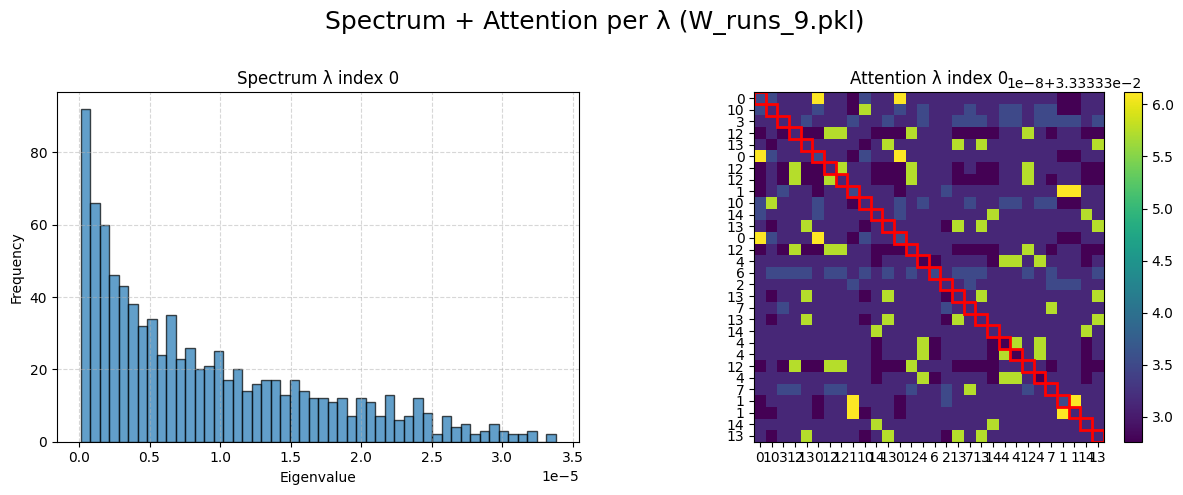

In [27]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw red rectangles on the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

# --- Path to your results directory ---
run_dir = f"../results/run_{run_id}"

# Load *both* types of files
W_files = sorted(glob.glob(os.path.join(run_dir, "W_runs_*.pkl")))
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_run*.pkl")))

print(f"Found {len(W_files)} W_runs files.")
print(f"Found {len(attn_files)} attn_run files.")

# --- Process each run synchronously ---
for W_file, attn_file in zip(W_files, attn_files):

    # ===== LOAD W spectrum data =====
    with open(W_file, "rb") as f:
        W_runs_all = pickle.load(f)  # list of length num_lambda

    num_lambda = len(W_runs_all)
    print(f"\n[RUN] Processing {W_file} & {attn_file} ({num_lambda} λ indices)")

    # ===== LOAD attention matrices =====
    with open(attn_file, "rb") as f:
        attn_data = pickle.load(f)

    attn_matrices = attn_data["attn_matrices"]
    seq_samples = attn_data["seq_samples"]

    # --- Use only min(len(attn_samples), num_lambda) to stay consistent
    n_plots = min(num_lambda, len(attn_matrices), 5)   # limit to 5 samples

    # Each λ → two plots → 2 columns
    fig, axes = plt.subplots(n_plots, 2, figsize=(12, 5*n_plots))

    if n_plots == 1:
        axes = np.array([axes])  # force 2D

    for i in range(n_plots):

        # ======== LEFT PLOT = Eigenvalue spectrum ========
        W_list = W_runs_all[i]
        eigvals_all = []

        for W in W_list:
            eigvals = np.linalg.eigvalsh(W @ W.T)  # Use eigvalsh for symmetric matrices - more stable (don't need constant factor)
            eigvals_all.extend(eigvals)

        eigvals_all = np.array(eigvals_all)

        ax_left = axes[i, 0]
        ax_left.hist(eigvals_all, bins=50, alpha=0.7, edgecolor='black')
        ax_left.set_title(f"Spectrum λ index {i}")
        ax_left.set_xlabel("Eigenvalue")
        ax_left.set_ylabel("Frequency")
        ax_left.grid(True, linestyle="--", alpha=0.5)

        # ======== RIGHT PLOT = Attention matrix ========
        attn_matrix_tensor = torch.tensor(attn_matrices[i])
        attn_matrix = attn_matrix_tensor[-1] if attn_matrix_tensor.ndim == 3 else attn_matrix_tensor
        
        seq_vals = np.array(seq_samples[i])
        if seq_vals.ndim == 2:
            seq_vals = seq_vals[-1]

        ax_right = axes[i, 1]
        im = ax_right.imshow(attn_matrix.numpy(), cmap='viridis')
        highlight_diagonal(ax_right, len(seq_vals))

        ax_right.set_xticks(np.arange(len(seq_vals)))
        ax_right.set_yticks(np.arange(len(seq_vals)))
        ax_right.set_xticklabels(seq_vals)
        ax_right.set_yticklabels(seq_vals)
        ax_right.set_title(f"Attention λ index {i}")

        fig.colorbar(im, ax=ax_right, fraction=0.046, pad=0.04)

    fig.suptitle(f"Spectrum + Attention per λ ({os.path.basename(W_file)})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
def plot_h_pred_vs_y_true(run_dir, max_samples=5):
    """
    Visualize h_pred_sample vs y_true_sample for each run in run_dir.
    """
    # Load pickle files
    files = sorted(glob.glob(os.path.join(run_dir, "h_pred_y_true_run*.pkl")))
    print(f"Found {len(files)} h_pred/y_true files.")

    for fpath in files:
        with open(fpath, "rb") as f:
            data = pickle.load(f)
        h_pred_samples = data["h_pred_samples"]
        y_true_samples = data["y_true_samples"]

        n_samples = min(max_samples, len(h_pred_samples))
        seq_len = len(h_pred_samples[0])

        fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3*n_samples))
        if n_samples == 1:
            axes = [axes]  # ensure iterable

        for i in range(n_samples):
            ax = axes[i]
            ax.plot(range(seq_len), h_pred_samples[i], color='blue', alpha=0.6, label='h_pred')
            ax.plot(range(seq_len), y_true_samples[i], color='orange', alpha=0.6, label='y_true')
            ax.set_title(f"Sample {i}")
            ax.set_xlabel("Position in sequence")
            ax.set_ylabel("Normalized count")
            ax.grid(True)
            if i == 0:
                ax.legend()
        fig.suptitle(f"h_pred vs y_true — {os.path.basename(fpath)}", fontsize=16)
        plt.tight_layout(rect=[0,0,1,0.96])
        plt.show()

# --- Example usage ---
run_dir = "../results/run_YYYYMMDD_HHMMSS"  # replace with your run directory
plot_h_pred_vs_y_true(run_dir)